<a href="https://colab.research.google.com/github/karna-charan/-Neural-Networks-and-Deep-Learning-/blob/main/projetcreditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [ ]:
file_path = "UCI_Credit_Card.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/default-of-credit-card-clients-dataset",
    file_path
)

/tmp/ipykernel_207/1290806807.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 0.98M/0.98M [00:00<00:00, 117MB/s]

Extracting zip of UCI_Credit_Card.csv...


In [ ]:
df.drop("ID", axis=1, inplace=True)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [ ]:
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
pay_status_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAYMENT'] = df[pay_amt_cols].sum(axis=1)
df['PAYMENT_RATIO'] = df['TOTAL_PAYMENT'] / (df['TOTAL_BILL'] + 1)
df['DELAY_COUNT'] = (df[pay_status_cols] > 0).sum(axis=1)

In [ ]:
df = pd.get_dummies(df, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)

In [ ]:
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

nn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=300,
    random_state=42
)
nn.fit(X_train_resampled, y_train_resampled)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

In [ ]:
def evaluate_model(model, X_data, y_true, name):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(f"{name}")
    print("==============================")
    print("Precision :", precision)
    print("Recall    :", recall)
    print("ROC-AUC   :", roc_auc)
    print(classification_report(y_true, y_pred))

In [ ]:
evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(xgb, X_test, y_test, "XGBoost")
evaluate_model(nn, X_test_scaled, y_test, "Neural Network")


Logistic Regression
Precision : 0.47195967233774416
Recall    : 0.5644310474755087
ROC-AUC   : 0.7474212115939327
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000


Random Forest
Precision : 0.6279683377308707
Recall    : 0.35870384325546345
ROC-AUC   : 0.759031222187264
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


XGBoost
Precision : 0.6616438356164384
Recall    : 0.36397889977392617
ROC-AUC   : 0.7765488413211202
              precis

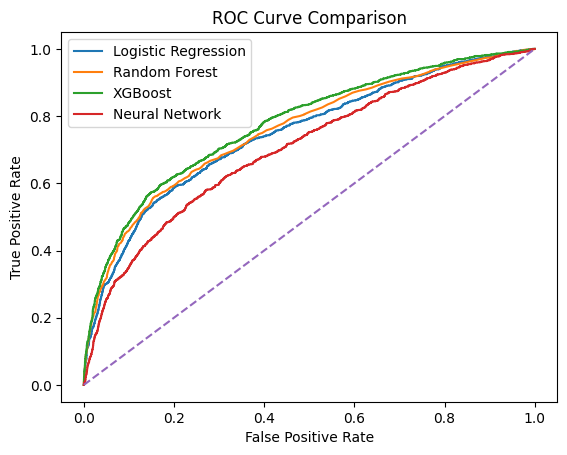

In [ ]:
plt.figure()

models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test),
    "Neural Network": (nn, X_test_scaled)
}

for name, (model, X_data) in models.items():
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
pip install streamlit joblib scikit-learn xgboost pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.6 MB/s eta 0:00:00


In [ ]:
import joblib

joblib.dump(xgb, "credit_default_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
#credit-default-app
#app.py
#credit_default_model.pkl
#scaler.pkl
#requirements.txt

In [ ]:
import streamlit as st
import numpy as np
import joblib

# Load model and scaler
model = joblib.load("credit_default_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("💳 Credit Card Default Prediction App")

st.write("Enter customer information to predict whether they will default next month.")

# User Inputs
limit_bal = st.number_input("Credit Limit", min_value=0)
age = st.number_input("Age", min_value=18, max_value=100)
pay_0 = st.number_input("Last Month Payment Status")
bill_amt1 = st.number_input("Last Bill Amount")
pay_amt1 = st.number_input("Last Payment Amount")

# Create feature array
features = np.array([[limit_bal, age, pay_0, bill_amt1, pay_amt1]])

if st.button("Predict"):

    features_scaled = scaler.transform(features)

    prediction = model.predict(features_scaled)

    if prediction[0] == 1:
        st.error("⚠ Customer is likely to DEFAULT payment")
    else:
        st.success("✅ Customer is NOT likely to default")

2026-03-11 11:07:49.836 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.921 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-11 11:07:49.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 11:07:49.925 Thread 'MainThread': mi

In [ ]:
#streamlit
#numpy
#pandas
#scikit-learn
#xgboost
#joblib

In [ ]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib
model = joblib.load("credit_default_model.pkl")
scaler = joblib.load("scaler.pkl")
st.title("💳 Credit Card Default Prediction App")
st.write("Enter customer information to predict whether they will default next month.")
limit_bal = st.number_input("Credit Limit", min_value=0)
age = st.number_input("Age", min_value=18, max_value=100)
pay_0 = st.number_input("Last Month Payment Status")
bill_amt1 = st.number_input("Last Bill Amount")
pay_amt1 = st.number_input("Last Payment Amount")
features = np.array([[limit_bal, age, pay_0, bill_amt1, pay_amt1]])
if st.button("Predict"):
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)
    if prediction[0] == 1:
        st.error("⚠ Customer is likely to DEFAULT payment")
    else:
        st.success("✅ Customer is NOT likely to default")

Writing app.py
